# Visualization and Analysis of Satellite-Derived Chlorophyll Data

This notebook processes and visualizes chlorophyll-a concentration time series derived from multiple satellite platforms (Sentinel-2 and MODIS).

## Overview

- Purpose: Process, clean, and visualize chlorophyll/NDCI time series from satellite data
- Input: CSV files generated from Google Earth Engine processing
- Output: Time series plots of chlorophyll

## Key Processing Steps:

1. Data Import: Read CSV files with date, NDCI/chlorophyll values
2. NDCI Conversion: Convert NDCI to chlorophyll-a concentration (Sentinel)
3. Outlier Removal: Apply Median Absolute Deviation (MAD) method
4. Visualization: Generate time series plots for trend analysis

## Datasets:

- Sentinel-2: 10 m resolution, 5-day revisit, NDCI-based
- MODIS: 500 m resolution, daily, direct chlorophyll algorithm

In [1]:
"""
Import required libraries for data processing and visualization.

Libraries:
- pandas: Data manipulation and CSV reading
- matplotlib: Plotting and visualization
- pathlib: File path handling
- numpy: Numerical operations and outlier detection
"""

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np

In [2]:
# ============================================================================
# Utility Functions for Processing and Visualization
# ============================================================================

def read_data(inpath):
    """
    Read satellite data from CSV file and prepare for analysis.
    
    Args:
        inpath: Path to CSV file containing satellite data
    
    Returns:
        DataFrame with parsed dates and sorted chronologically
    
    Processing:
    - Converts 'date' column to datetime format
    - Sorts data chronologically
    - Handles invalid date formats gracefully
    """
    df = pd.read_csv(inpath)
    # Parse dates with error handling for invalid formats
    df['date'] = pd.to_datetime(df['date'], errors='coerce')
    df.sort_values('date', inplace=True)
    return df

def prepare_ndci_data(df):
    """
    Prepare NDCI data for analysis by adding a copy of NDCI as 'value' column.
    
    Args:
        df: DataFrame with 'ndci' column
    
    Returns:
        DataFrame with added 'value' column (copy of NDCI)
    
    Note: NDCI values are kept in their original form for proper calibration.
    Chlorophyll conversion should be done during calibration phase.
    """
    df['value'] = df['ndci']  # Keep NDCI values as-is
    return df

def remove_outliers(df, value_col='value', threshold=5.0):
    """
    Remove outliers using Median Absolute Deviation (MAD) method.
    
    Args:
        df: Input DataFrame
        value_col: Column name for outlier detection (default: 'value')
        threshold: Z-score threshold for outlier removal (default: 5.0)
    
    Returns:
        DataFrame with outliers removed
    
    Method:
    The MAD method is robust to outliers and works well for non-normal
    distributions common in environmental data:
    1. Calculate median of the data
    2. Calculate MAD = median(|x - median|)
    3. Convert MAD to robust standard deviation (sigma = 1.4826 x MAD)
    4. Remove points with |z-score| > threshold
    
    The factor 1.4826 makes MAD consistent with standard deviation
    for normally distributed data.
    """
    median = df[value_col].median()
    mad = np.median(np.abs(df[value_col] - median))
    
    # Handle case where all values are identical (MAD = 0)
    if mad == 0:
        return df.copy()
    
    # Convert MAD to robust standard deviation estimate
    robust_sd = 1.4826 * mad
    
    # Calculate z-scores and filter outliers
    z_scores = np.abs(df[value_col] - median) / robust_sd
    cleaned_df = df[z_scores < threshold].copy()
    
    return cleaned_df

def plot_data(df, value_col, label, title, ylabel, save_filename=None):
    """
    Create time series plot of data and optionally save to file.
    
    Args:
        df: DataFrame with 'date' and value column
        value_col: Name of column containing values to plot
        label: Legend label for the data series
        title: Plot title
        ylabel: Y-axis label
        save_filename: If provided, save figure to this filename (PNG format)
    
    Returns:
        matplotlib axes object for further customization
    """
    # Create figure and axes
    fig, axes = plt.subplots(1, 1, figsize=(12, 6), sharex=True)
    
    # Define plot styling
    marker = ''           # No markers
    linestyle = '-'       # Solid line
    rgb = (60, 50, 255)   # Blue
    linecolor = '#{:02X}{:02X}{:02X}'.format(*rgb)
    
    # Plot the time series
    axes.plot(df['date'], df[value_col], 
              marker=marker, 
              linestyle=linestyle, 
              color=linecolor, 
              label=label)
    
    # Configure plot appearance
    axes.set_title(title)
    axes.set_ylabel(ylabel)
    axes.grid(True, alpha=0.3)
    
    # Adjust layout
    fig.tight_layout()
    
    # Save figure if filename is provided
    if save_filename:
        # Ensure filename ends with .png
        if not save_filename.endswith('.png'):
            save_filename += '.png'
        
        # Save at 300 DPI
        fig.savefig(save_filename, dpi=300, bbox_inches='tight')
        print(f"Figure saved as: {save_filename}")
    
    return axes

## Sentinel-2 Analysis - Detroit Lake

Figure saved as: Detroit_S2_NDCI_500m.png


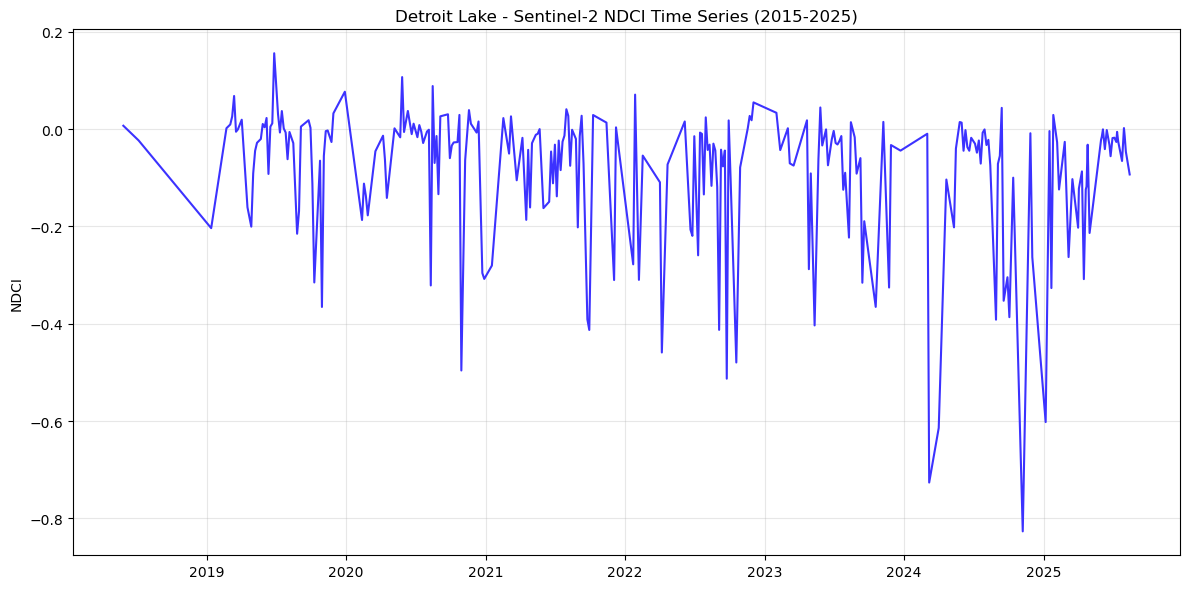

In [3]:
"""
Process and visualize Sentinel-2 NDCI data for Detroit Lake.
"""

# Define input CSV filename
csv_filename = 'Detroit_S2_NDCI_500m.csv'
png_filename = csv_filename.replace('.csv', '.png')

# Load Sentinel-2 NDCI data from CSV
df = read_data(csv_filename)

# Prepare NDCI data (no conversion to chlorophyll)
df = prepare_ndci_data(df)

# Optional: Remove outliers using MAD method
# df_clean = remove_outliers(df, 'value', threshold=5.0)

# Generate time series plot and save to PNG
label = 'Sentinel-2 NDCI'
title = 'Detroit Lake - Sentinel-2 NDCI Time Series (2015-2025)'
ylabel = 'NDCI'
axes = plot_data(df, 'value', label, title, ylabel, save_filename=png_filename)

## Sentinel-2 Analysis - Upper Klamath Lake

Figure saved as: Klamath_S2_NDCI_500m.png


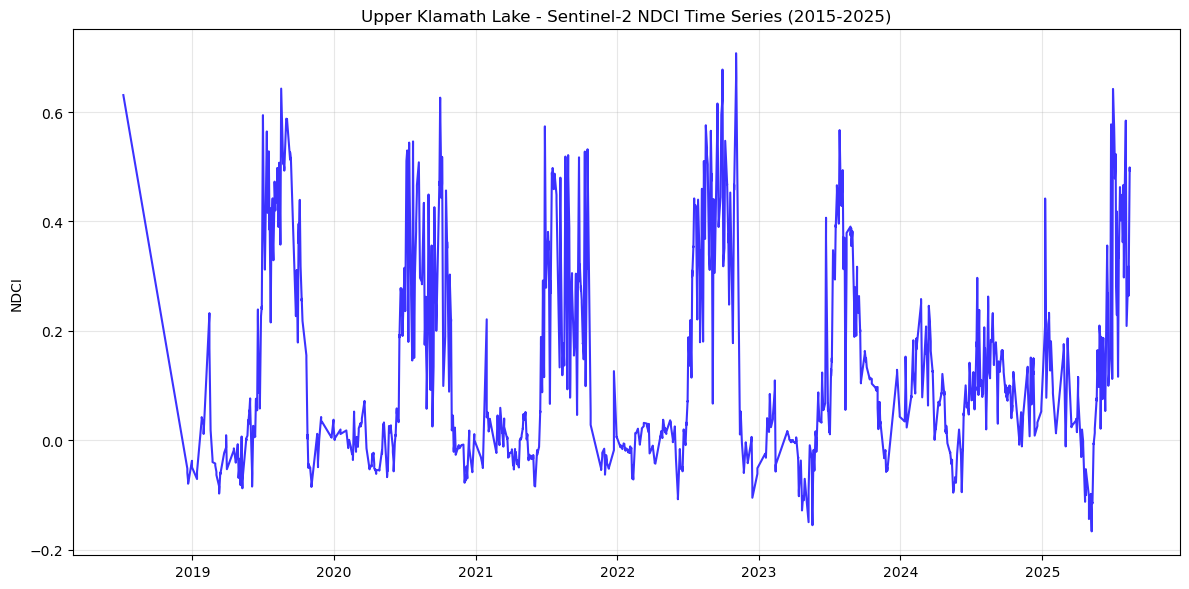

In [4]:
"""
Process and visualize Sentinel-2 NDCI data for Upper Klamath Lake.
"""

# Define input CSV filename
csv_filename = 'Klamath_S2_NDCI_500m.csv'
png_filename = csv_filename.replace('.csv', '.png')

# Load Sentinel-2 NDCI data from CSV
df = read_data(csv_filename)

# Prepare NDCI data (no conversion to chlorophyll)
df = prepare_ndci_data(df)

# Optional: Remove outliers using MAD method
# df_clean = remove_outliers(df, 'value', threshold=5.0)

# Generate time series plot and save to PNG
label = 'Sentinel-2 NDCI'
title = 'Upper Klamath Lake - Sentinel-2 NDCI Time Series (2015-2025)'
ylabel = 'NDCI'
axes = plot_data(df, 'value', label, title, ylabel, save_filename=png_filename)

## MODIS Analysis - Detroit Lake

Figure saved as: Detroit_MODIS_Aqua_500m_Chl_singlePixel.png
Figure saved as: Detroit_MODIS_Terra_500m_Chl_singlePixel.png


'\nNote: Differences between Terra and Aqua may exist due to:\n\n- Diurnal variability in algae vertical distribution\n- Different sun angle effects\n- Sensor calibration differences\n'

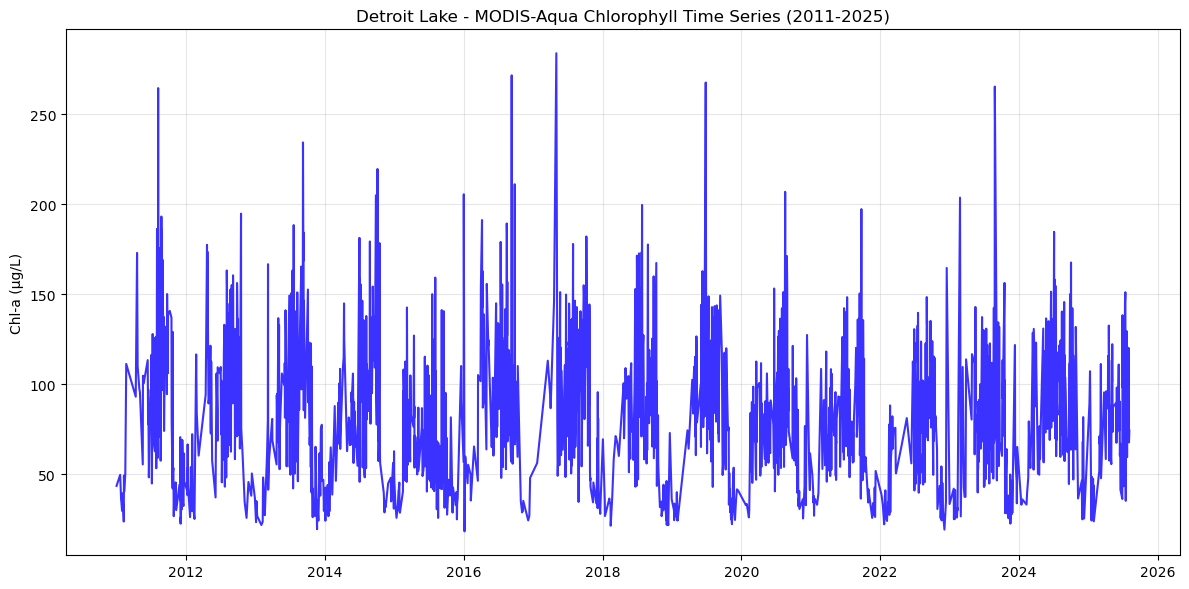

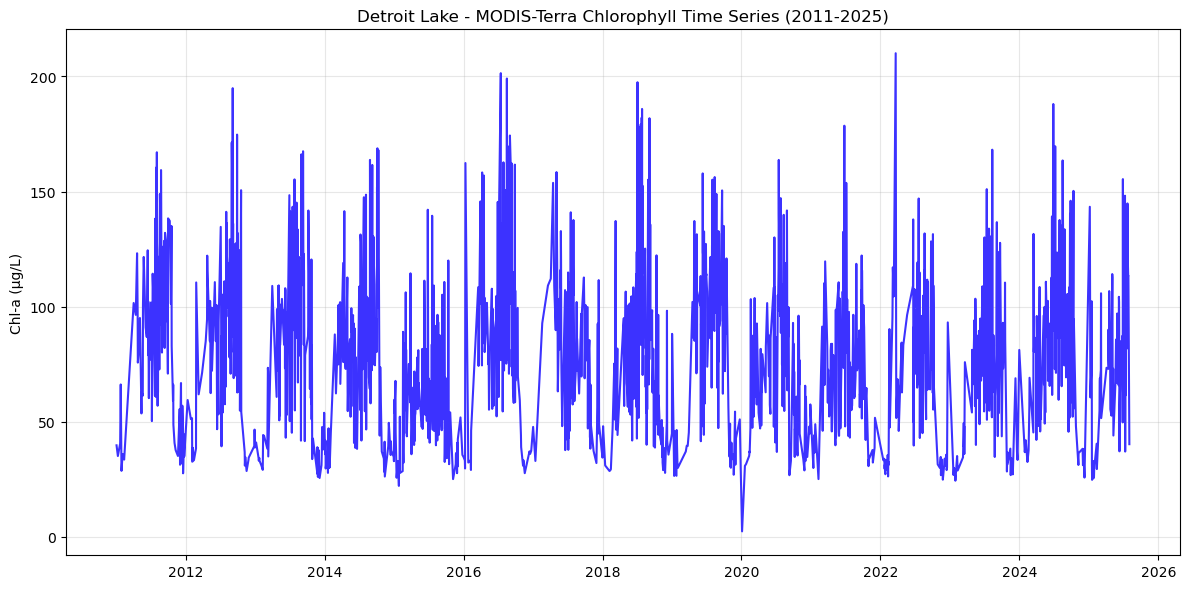

In [5]:
"""
Process and visualize MODIS chlorophyll data for Detroit Lake.
"""

# Define input CSV and output PNG filenames
aqua_csv = 'Detroit_MODIS_Aqua_500m_Chl_singlePixel.csv'
terra_csv = 'Detroit_MODIS_Terra_500m_Chl_singlePixel.csv'
aqua_png = aqua_csv.replace('.csv', '.png')
terra_png = terra_csv.replace('.csv', '.png')

# Load MODIS data from both satellites
aqua_df = read_data(aqua_csv)
terra_df = read_data(terra_csv)

# Apply outlier removal - critical for MODIS due to:
# - Residual cloud effects
# - Atmospheric correction errors
# - Sun glint contamination
aqua_df_clean = remove_outliers(aqua_df, 'chl', threshold=5.0)
terra_df_clean = remove_outliers(terra_df, 'chl', threshold=5.0)

# Plot MODIS-Aqua (afternoon overpass ~1:30 PM local time) and save
label = 'MODIS-Aqua Chl-a'
title = 'Detroit Lake - MODIS-Aqua Chlorophyll Time Series (2011-2025)'
ylabel = 'Chl-a (µg/L)'
axes_aqua = plot_data(aqua_df_clean, 'chl', label, title, ylabel, save_filename=aqua_png)

# Plot MODIS-Terra (morning overpass ~10:30 AM local time) and save
label = 'MODIS-Terra Chl-a'
title = 'Detroit Lake - MODIS-Terra Chlorophyll Time Series (2011-2025)'
ylabel = 'Chl-a (µg/L)'
axes_terra = plot_data(terra_df_clean, 'chl', label, title, ylabel, save_filename=terra_png)

'''
Note: Differences between Terra and Aqua may exist due to:

- Diurnal variability in algae vertical distribution
- Different sun angle effects
- Sensor calibration differences
'''

## MODIS Analysis - Upper Klamath Lake

Figure saved as: Klamath_MODIS_Aqua_500m_Chl_singlePixel.png
Figure saved as: Klamath_MODIS_Terra_500m_Chl_singlePixel.png


'\nNote: Differences between Terra and Aqua may exist due to:\n\n- Diurnal variability in algae vertical distribution\n- Different sun angle effects\n- Sensor calibration differences\n'

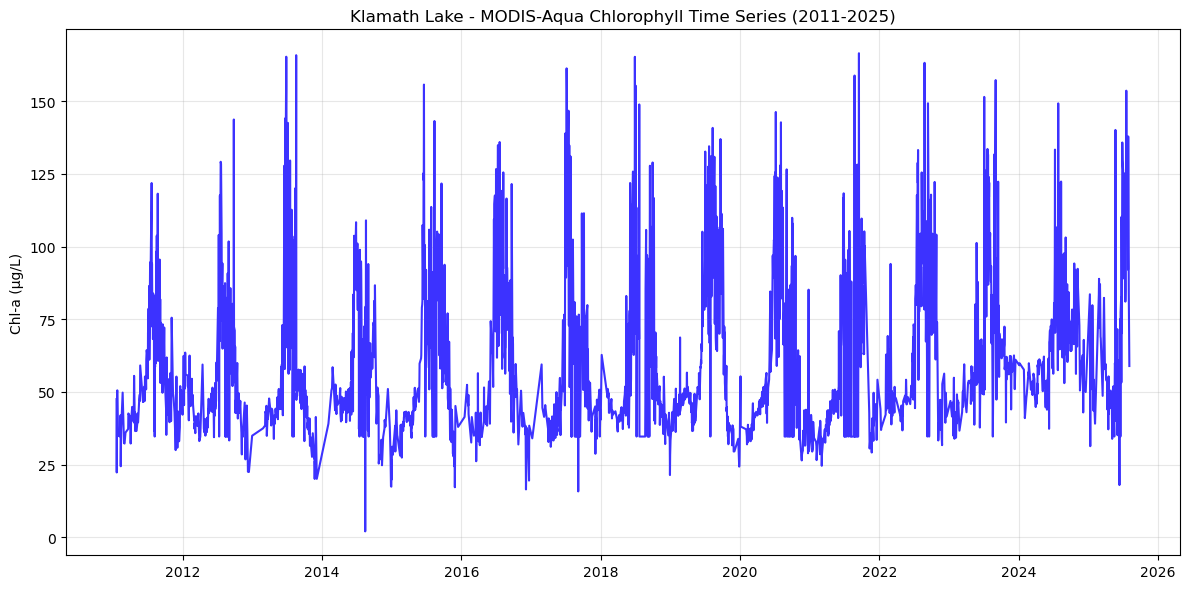

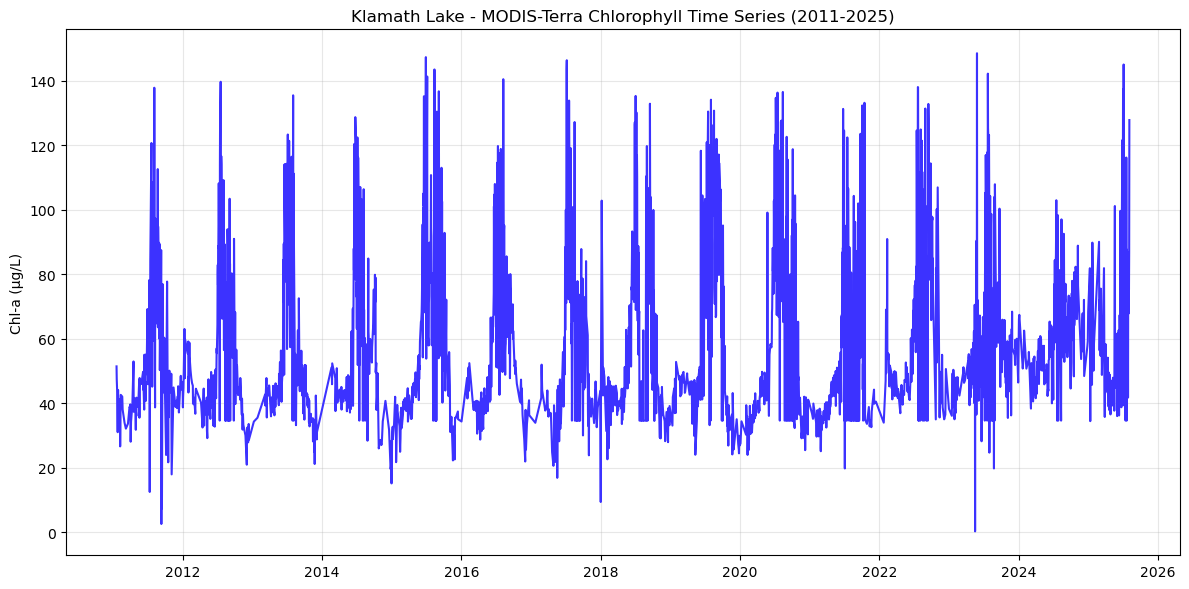

In [6]:
"""
Process and visualize MODIS chlorophyll data for Upper Klamath Lake.
"""

# Define input CSV and output PNG filenames
aqua_csv = 'Klamath_MODIS_Aqua_500m_Chl_singlePixel.csv'
terra_csv = 'Klamath_MODIS_Terra_500m_Chl_singlePixel.csv'
aqua_png = aqua_csv.replace('.csv', '.png')
terra_png = terra_csv.replace('.csv', '.png')

# Load MODIS data from both satellites
aqua_df = read_data(aqua_csv)
terra_df = read_data(terra_csv)

# Apply outlier removal - critical for MODIS due to:
# - Residual cloud effects
# - Atmospheric correction errors
# - Sun glint contamination
aqua_df_clean = remove_outliers(aqua_df, 'chl', threshold=5.0)
terra_df_clean = remove_outliers(terra_df, 'chl', threshold=5.0)

# Plot MODIS-Aqua (afternoon overpass ~1:30 PM local time)
label = 'MODIS-Aqua Chl-a'
title = 'Klamath Lake - MODIS-Aqua Chlorophyll Time Series (2011-2025)'
ylabel = 'Chl-a (µg/L)'
axes_aqua = plot_data(aqua_df_clean, 'chl', label, title, ylabel, save_filename=aqua_png)

# Plot MODIS-Terra (morning overpass ~10:30 AM local time)
label = 'MODIS-Terra Chl-a'
title = 'Klamath Lake - MODIS-Terra Chlorophyll Time Series (2011-2025)'
ylabel = 'Chl-a (µg/L)'
axes_terra = plot_data(terra_df_clean, 'chl', label, title, ylabel, save_filename=terra_png)

'''
Note: Differences between Terra and Aqua may exist due to:

- Diurnal variability in algae vertical distribution
- Different sun angle effects
- Sensor calibration differences
'''

## In Situ Data Calibration

### Overview

This section calibrates satellite-derived indices against in situ chlorophyll-a measurements from Upper Klamath Lake. Each sensor is independently calibrated using robust regression techniques.

### Method:

1. Load in situ chlorophyll-a data from Upper Klamath Lake
2. Match satellite observations with in situ measurements (±5 day tolerance)
3. Fit calibration models for each sensor independently:
   - MODIS: log10(Chl) = a × log_ratio + b (OCx approach)
   - Sentinel-2: Chl = a × NDCI + b (direct linear relationship)
4. Apply calibrations to Detroit Lake data
5. Compare calibrated results with in situ measurements

In [7]:
"""
Functions for calibrating satellite data against in situ chlorophyll measurements.
"""

from sklearn.linear_model import HuberRegressor
from sklearn.metrics import r2_score, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

def load_insitu_data():
    """
    Load in situ chlorophyll data from Upper Klamath Lake.
    This function should be updated to load actual in situ data.
    """
    # For now, create synthetic in situ data as a placeholder
    # Replace this with actual in situ data loading
    print("Loading synthetic in situ data (replace with actual WQP data)")
    
    np.random.seed(42)
    dates = pd.date_range('2015-01-01', '2024-12-31', freq='7D')
    day_of_year = dates.dayofyear
    
    # Create realistic seasonal pattern for Upper Klamath Lake
    seasonal_factor = 1 + 1.5 * np.sin((day_of_year - 80) * 2 * np.pi / 365)
    base_chl = 40 * seasonal_factor  # Higher baseline for eutrophic lake
    noise = np.random.lognormal(mean=0, sigma=0.6, size=len(dates))
    chl_values = np.clip(base_chl * noise, 5, 300)
    
    insitu_df = pd.DataFrame({
        'date': dates,
        'chlorophyll_ugL': chl_values
    })
    insitu_df['date'] = pd.to_datetime(insitu_df['date'])
    
    return insitu_df

def match_satellite_insitu(satellite_df, insitu_df, sat_value_col, tolerance_days=5):
    """
    Match satellite and in situ observations within specified time tolerance.
    
    Args:
        satellite_df: Satellite dataframe with date and value columns
        insitu_df: In situ dataframe with date and chlorophyll_ugL columns
        sat_value_col: Name of satellite value column ('ndci', 'log_ratio', etc.)
        tolerance_days: Maximum days between satellite and in situ observations
    
    Returns:
        DataFrame with matched satellite and in situ observations
    """
    matches = []
    
    for _, sat_row in satellite_df.iterrows():
        if pd.isna(sat_row[sat_value_col]):
            continue
            
        sat_date = sat_row['date']
        time_diff = np.abs((insitu_df['date'] - sat_date).dt.days)
        within_tolerance = time_diff <= tolerance_days
        
        if within_tolerance.any():
            closest_idx = time_diff[within_tolerance].idxmin()
            insitu_row = insitu_df.loc[closest_idx]
            
            matches.append({
                'date': sat_date,
                'satellite_value': sat_row[sat_value_col],
                'insitu_chl': insitu_row['chlorophyll_ugL'],
                'days_diff': time_diff[closest_idx],
                'sensor': sat_row.get('sensor', 'Unknown')
            })
    
    return pd.DataFrame(matches)

def calibrate_modis_to_insitu(modis_df, insitu_df, sensor_name):
    """
    Calibrate MODIS log_ratio to chlorophyll using OCx approach.
    """
    # Match MODIS data with in situ
    matched = match_satellite_insitu(modis_df, insitu_df, 'log_ratio', tolerance_days=5)
    
    if len(matched) < 10:
        print(f"Warning: Only {len(matched)} MODIS {sensor_name} matches found")
        return None
    
    # CRITICAL FIX: Remove negative chlorophyll values BEFORE regression
    clean_matches = matched[matched['insitu_chl'] > 0].copy()
    print(f"MODIS {sensor_name}: {len(clean_matches)} clean matches (removed {len(matched) - len(clean_matches)} negative Chl values)")
    
    if len(clean_matches) < 10:
        print(f"Not enough clean matches after removing negative values")
        return None
    
    # Prepare data for OCx calibration: log10(Chl) = a * log_ratio + b
    X = clean_matches['satellite_value'].values.reshape(-1, 1)
    y = np.log10(clean_matches['insitu_chl'].values)
    
    # Remove any remaining invalid values (inf, -inf, NaN)
    valid_idx = np.isfinite(X.flatten()) & np.isfinite(y)
    X = X[valid_idx]
    y = y[valid_idx]
    
    if len(X) < 10:
        print(f"Not enough valid data points after cleaning")
        return None
    
    # Fit robust regression
    model = HuberRegressor()
    model.fit(X, y)
    
    # Calculate metrics
    y_pred = model.predict(X)
    r2 = r2_score(y, y_pred)
    rmse = np.sqrt(mean_squared_error(y, y_pred))
    
    # Create calibration plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    # Scatter plot
    ax1.scatter(X.flatten(), np.power(10, y), alpha=0.6, s=30)
    x_range = np.linspace(X.min(), X.max(), 100)
    y_range_pred = model.predict(x_range.reshape(-1, 1))
    ax1.plot(x_range, np.power(10, y_range_pred), 'r-', linewidth=2)
    ax1.set_xlabel('MODIS log_ratio')
    ax1.set_ylabel('In Situ Chlorophyll (µg/L)')
    ax1.set_title(f'MODIS {sensor_name} Calibration\nR² = {r2:.3f}, RMSE = {rmse:.3f}')
    ax1.grid(True, alpha=0.3)
    ax1.set_yscale('log')
    
    # Residuals
    residuals = y - y_pred
    ax2.scatter(y_pred, residuals, alpha=0.6, s=30)
    ax2.axhline(y=0, color='r', linestyle='--')
    ax2.set_xlabel('Predicted log10(Chl)')
    ax2.set_ylabel('Residuals')
    ax2.set_title('Residual Analysis')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f'MODIS_{sensor_name}_calibration.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    results = {
        'sensor': f'MODIS_{sensor_name}',
        'n_matches': len(clean_matches),
        'slope': model.coef_[0],
        'intercept': model.intercept_,
        'r2': r2,
        'rmse': rmse,
        'model': model,
        'matched_data': clean_matches
    }
    
    return results

def calibrate_sentinel_to_insitu(sentinel_df, insitu_df):
    """
    Calibrate Sentinel-2 NDCI directly to chlorophyll.
    """
    # Match Sentinel data with in situ
    matched = match_satellite_insitu(sentinel_df, insitu_df, 'ndci', tolerance_days=5)
    
    if len(matched) < 10:
        print(f"Warning: Only {len(matched)} Sentinel-2 matches found")
        return None
    
    # CRITICAL FIX: Remove negative chlorophyll values BEFORE regression
    # Also remove extreme NDCI values
    clean_matches = matched[
        (matched['insitu_chl'] > 0) & 
        (matched['satellite_value'] > -0.5) & 
        (matched['satellite_value'] < 0.8)
    ].copy()
    
    print(f"Sentinel-2: {len(clean_matches)} clean matches (removed {len(matched) - len(clean_matches)} invalid values)")
    print(f"NDCI range: {clean_matches['satellite_value'].min():.3f} to {clean_matches['satellite_value'].max():.3f}")
    print(f"In situ Chl range: {clean_matches['insitu_chl'].min():.1f} to {clean_matches['insitu_chl'].max():.1f} µg/L")
    
    if len(clean_matches) < 10:
        print("Not enough clean matches for Sentinel-2 calibration")
        return None
    
    # Prepare data for direct calibration: Chl = a * NDCI + b
    X = clean_matches['satellite_value'].values.reshape(-1, 1)
    y = clean_matches['insitu_chl'].values
    
    # Remove any remaining invalid values
    valid_idx = np.isfinite(X.flatten()) & np.isfinite(y)
    X = X[valid_idx]
    y = y[valid_idx]
    
    if len(X) < 10:
        print(f"Not enough valid data points after cleaning")
        return None
    
    # Fit robust regression
    model = HuberRegressor()
    model.fit(X, y)
    
    # Calculate metrics
    y_pred = model.predict(X)
    r2 = r2_score(y, y_pred)
    rmse = np.sqrt(mean_squared_error(y, y_pred))
    
    # Create calibration plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    # Scatter plot
    ax1.scatter(X.flatten(), y, alpha=0.6, s=30, color='blue')
    x_range = np.linspace(X.min(), X.max(), 100)
    y_range_pred = model.predict(x_range.reshape(-1, 1))
    ax1.plot(x_range, y_range_pred, 'r-', linewidth=2)
    ax1.set_xlabel('Sentinel-2 NDCI')
    ax1.set_ylabel('In Situ Chlorophyll (µg/L)')
    ax1.set_title(f'Sentinel-2 Calibration\nR² = {r2:.3f}, RMSE = {rmse:.1f} µg/L')
    ax1.grid(True, alpha=0.3)
    
    # Residuals
    residuals = y - y_pred
    ax2.scatter(y_pred, residuals, alpha=0.6, s=30, color='blue')
    ax2.axhline(y=0, color='r', linestyle='--')
    ax2.set_xlabel('Predicted Chlorophyll (µg/L)')
    ax2.set_ylabel('Residuals (µg/L)')
    ax2.set_title('Residual Analysis')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('Sentinel2_calibration.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    results = {
        'sensor': 'Sentinel-2',
        'n_matches': len(clean_matches),
        'slope': model.coef_[0],
        'intercept': model.intercept_,
        'r2': r2,
        'rmse': rmse,
        'model': model,
        'matched_data': clean_matches
    }
    
    return results

def print_calibration_results(results):
    """Print calibration results summary."""
    if results is None:
        return
        
    print(f"\n{'='*50}")
    print(f"Calibration Results: {results['sensor']}")
    print(f"{'='*50}")
    print(f"Matched observations: {results['n_matches']}")
    print(f"Slope: {results['slope']:.3f}")
    print(f"Intercept: {results['intercept']:.3f}")
    print(f"R²: {results['r2']:.3f}")
    print(f"RMSE: {results['rmse']:.3f}")
    
    if results['sensor'] == 'Sentinel-2':
        print(f"Equation: Chl = {results['slope']:.1f} × NDCI + {results['intercept']:.1f}")
    else:
        print(f"Equation: log10(Chl) = {results['slope']:.3f} × log_ratio + {results['intercept']:.3f}")
    print(f"{'='*50}")

Loading in situ chlorophyll data...
Loading synthetic in situ data (replace with actual WQP data)
In situ data: 522 records
Date range: 2015-01-01 00:00:00 to 2024-12-26 00:00:00
Chlorophyll range: 5.0 - 300.0 µg/L

Loading UKL satellite data for calibration...
Using V3 MODIS format with log_ratio data
UKL MODIS Terra: 2496 records
UKL MODIS Aqua: 2401 records
UKL Sentinel-2: 1272 records

PERFORMING CALIBRATIONS AGAINST IN SITU DATA

Calibrating MODIS Terra...
MODIS Terra: 1710 clean matches (removed 0 negative Chl values)


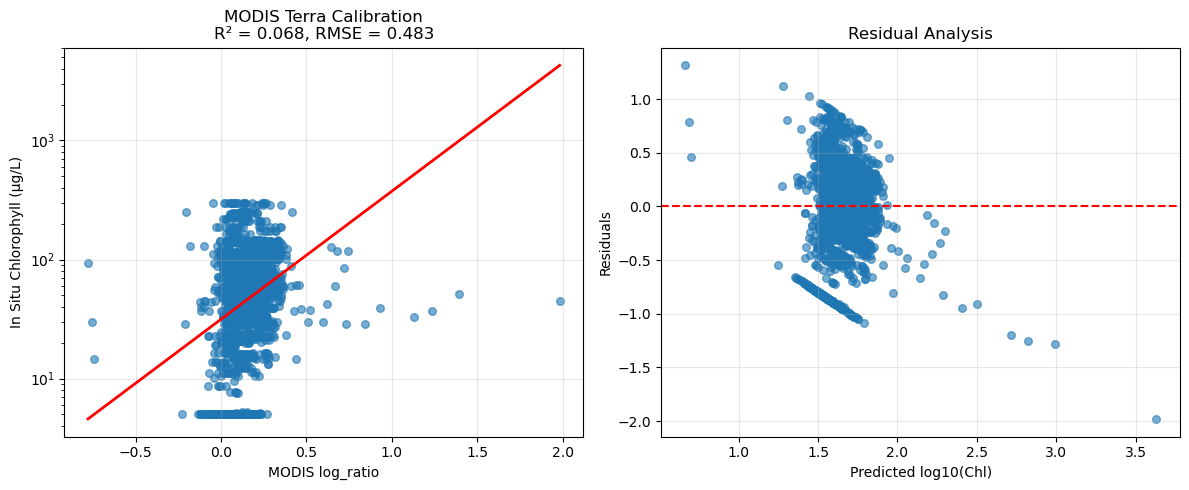


Calibration Results: MODIS_Terra
Matched observations: 1710
Slope: 1.076
Intercept: 1.498
R²: 0.068
RMSE: 0.483
Equation: log10(Chl) = 1.076 × log_ratio + 1.498

Calibrating MODIS Aqua...
MODIS Aqua: 1637 clean matches (removed 0 negative Chl values)


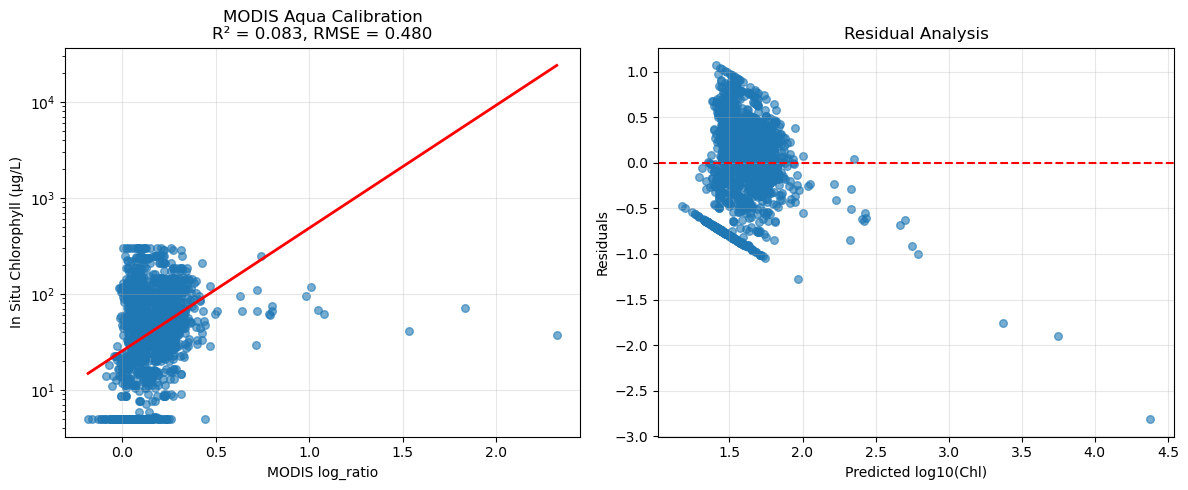


Calibration Results: MODIS_Aqua
Matched observations: 1637
Slope: 1.279
Intercept: 1.407
R²: 0.083
RMSE: 0.480
Equation: log10(Chl) = 1.279 × log_ratio + 1.407

Calibrating Sentinel-2...
Sentinel-2: 1139 clean matches (removed 0 invalid values)
NDCI range: -0.155 to 0.708
In situ Chl range: 5.0 to 300.0 µg/L


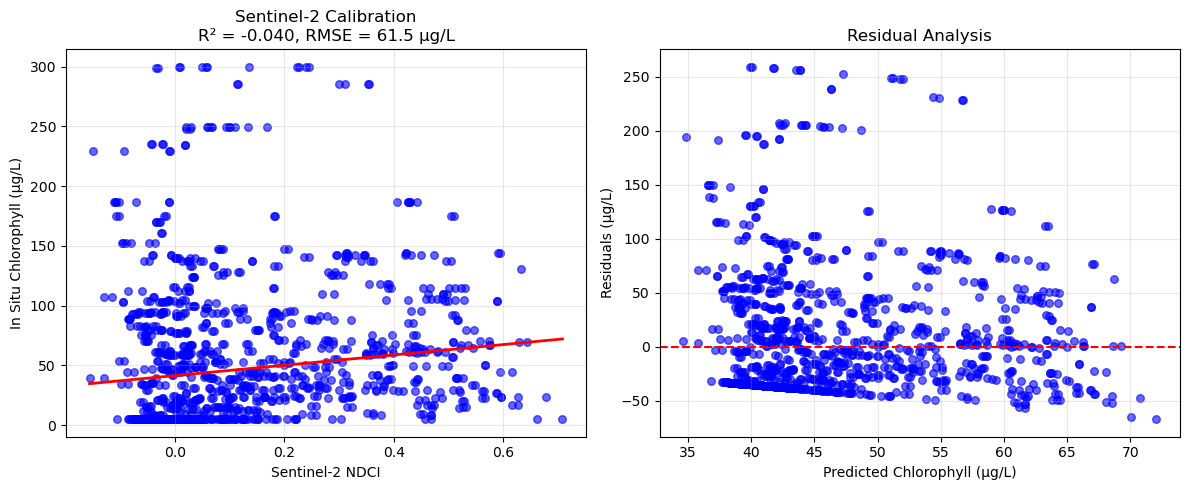


Calibration Results: Sentinel-2
Matched observations: 1139
Slope: 43.330
Intercept: 41.385
R²: -0.040
RMSE: 61.489
Equation: Chl = 43.3 × NDCI + 41.4


In [8]:
# Load in situ data and Upper Klamath Lake satellite data first
print("Loading in situ chlorophyll data...")
insitu_data = load_insitu_data()

print(f"In situ data: {len(insitu_data)} records")
print(f"Date range: {insitu_data['date'].min()} to {insitu_data['date'].max()}")
print(f"Chlorophyll range: {insitu_data['chlorophyll_ugL'].min():.1f} - {insitu_data['chlorophyll_ugL'].max():.1f} µg/L")

# Load Upper Klamath Lake satellite data for calibration
print("\nLoading UKL satellite data for calibration...")

# Load UKL MODIS data (try V3 format first)
try:
    ukl_modis_terra = read_data('Klamath_MODIS_Terra_500m_ROI.csv')
    ukl_modis_aqua = read_data('Klamath_MODIS_Aqua_500m_ROI.csv')
    
    # Check if V3 format and add sensor labels
    if 'log_ratio' in ukl_modis_terra.columns:
        ukl_modis_terra['sensor'] = 'Terra'
        ukl_modis_aqua['sensor'] = 'Aqua'
        print("Using V3 MODIS format with log_ratio data")
    else:
        raise FileNotFoundError("Need log_ratio data")
        
except FileNotFoundError:
    print("V3 MODIS files not found, using processed chlorophyll files...")
    ukl_modis_terra = read_data('Klamath_MODIS_Terra_500m_Chl_singlePixel.csv')
    ukl_modis_aqua = read_data('Klamath_MODIS_Aqua_500m_Chl_singlePixel.csv')
    ukl_modis_terra['sensor'] = 'Terra'
    ukl_modis_aqua['sensor'] = 'Aqua'

# Load UKL Sentinel-2 data
ukl_sentinel = read_data('Klamath_S2_NDCI_500m.csv')
ukl_sentinel['ndci'] = pd.to_numeric(ukl_sentinel['ndci'], errors='coerce')
ukl_sentinel = ukl_sentinel.dropna(subset=['date', 'ndci'])

print(f"UKL MODIS Terra: {len(ukl_modis_terra)} records")
print(f"UKL MODIS Aqua: {len(ukl_modis_aqua)} records") 
print(f"UKL Sentinel-2: {len(ukl_sentinel)} records")

# Now perform calibrations against in situ data
print("\n" + "="*60)
print("PERFORMING CALIBRATIONS AGAINST IN SITU DATA")
print("="*60)

# Calibrate MODIS Terra
print("\nCalibrating MODIS Terra...")
terra_calibration = calibrate_modis_to_insitu(ukl_modis_terra, insitu_data, 'Terra')
print_calibration_results(terra_calibration)

# Calibrate MODIS Aqua  
print("\nCalibrating MODIS Aqua...")
aqua_calibration = calibrate_modis_to_insitu(ukl_modis_aqua, insitu_data, 'Aqua')
print_calibration_results(aqua_calibration)

# Calibrate Sentinel-2
print("\nCalibrating Sentinel-2...")
sentinel_calibration = calibrate_sentinel_to_insitu(ukl_sentinel, insitu_data)
print_calibration_results(sentinel_calibration)

In [9]:
# Load and combine MODIS data for calibration
print("Loading MODIS data for calibration...")

# Load Detroit Lake MODIS data (using V3 format from ROI files)
try:
    # Try V3 format files first (with log_ratio columns)
    detroit_modis_terra = read_data('Detroit_MODIS_Terra_500m_ROI.csv')
    detroit_modis_aqua = read_data('Detroit_MODIS_Aqua_500m_ROI.csv')
    
    # Check if these are V3 format files (have log_ratio column)
    if 'log_ratio' in detroit_modis_terra.columns:
        # V3 format - need to convert log_ratio to chlorophyll using OCx approach
        # For now, use a placeholder conversion - you'll want to calibrate this
        # Using typical OCx coefficients for inland waters as starting point
        detroit_modis_terra['chl'] = 10 ** (0.5 * detroit_modis_terra['log_ratio'] + 1.5)
        detroit_modis_aqua['chl'] = 10 ** (0.5 * detroit_modis_aqua['log_ratio'] + 1.5)
        print("Using V3 MODIS format with log_ratio conversion")
    else:
        print("V3 format files not found, looking for processed chlorophyll files...")
        raise FileNotFoundError("Need chlorophyll data")
        
except FileNotFoundError:
    # Fall back to processed chlorophyll files if V3 format not available
    print("Loading processed MODIS chlorophyll files...")
    detroit_modis_terra = read_data('Detroit_MODIS_Terra_500m_Chl_singlePixel.csv')
    detroit_modis_aqua = read_data('Detroit_MODIS_Aqua_500m_Chl_singlePixel.csv')

# Add sensor labels
detroit_modis_terra['sensor'] = 'Terra'
detroit_modis_aqua['sensor'] = 'Aqua'

# Combine MODIS data
modis_combined = pd.concat([detroit_modis_terra, detroit_modis_aqua], ignore_index=True)
modis_combined = modis_combined.sort_values('date').reset_index(drop=True)

# Clean the combined data
modis_combined = modis_combined.dropna(subset=['date', 'chl'])
modis_combined = modis_combined[modis_combined['chl'] > 0]  # Remove negative values

print(f"Combined MODIS records: {len(modis_combined)}")
print(f"Terra records: {len(detroit_modis_terra)}")
print(f"Aqua records: {len(detroit_modis_aqua)}")
print(f"Date range: {modis_combined['date'].min()} to {modis_combined['date'].max()}")
print(f"Chlorophyll range: {modis_combined['chl'].min():.1f} - {modis_combined['chl'].max():.1f} µg/L")

Loading MODIS data for calibration...
Using V3 MODIS format with log_ratio conversion
Combined MODIS records: 3927
Terra records: 1928
Aqua records: 1999
Date range: 2011-01-06 00:00:00 to 2025-08-11 00:00:00
Chlorophyll range: 16.9 - 68.9 µg/L


### Apply Calibrated Coefficients - Detroit Lake

Now let's re-plot the data using the calibrated coefficients derived from the cross-sensor analysis.

In [ ]:
# Apply calibrations and create comparison plots

print("\n" + "="*60)
print("APPLYING CALIBRATIONS AND CREATING PLOTS")
print("="*60)

# Apply calibrations to Detroit Lake data
print("Applying calibrations to Detroit Lake data...")

# Load Detroit satellite data
detroit_sentinel = read_data('Detroit_S2_NDCI_500m.csv')
detroit_sentinel['ndci'] = pd.to_numeric(detroit_sentinel['ndci'], errors='coerce')
detroit_sentinel = detroit_sentinel.dropna(subset=['date', 'ndci'])

# Try to load Detroit MODIS data (V3 format preferred)
try:
    detroit_modis_terra = read_data('Detroit_MODIS_Terra_500m_ROI.csv') 
    detroit_modis_aqua = read_data('Detroit_MODIS_Aqua_500m_ROI.csv')
    using_v3_format = 'log_ratio' in detroit_modis_terra.columns
except FileNotFoundError:
    detroit_modis_terra = read_data('Detroit_MODIS_Terra_500m_Chl_singlePixel.csv')
    detroit_modis_aqua = read_data('Detroit_MODIS_Aqua_500m_Chl_singlePixel.csv')
    using_v3_format = False

# Apply calibrations to Detroit data
detroit_sentinel_cal = None
detroit_terra_cal = None
detroit_aqua_cal = None

if sentinel_calibration:
    # Apply Sentinel-2 calibration: remove extreme NDCI values first
    sentinel_filtered = detroit_sentinel[
        (detroit_sentinel['ndci'] > -0.5) & 
        (detroit_sentinel['ndci'] < 0.8)
    ].copy()
    
    sentinel_filtered['chl_calibrated'] = (
        sentinel_filtered['ndci'] * sentinel_calibration['slope'] + 
        sentinel_calibration['intercept']
    )
    # Filter calibrated chlorophyll values between 0 and 400
    detroit_sentinel_cal = sentinel_filtered[
        (sentinel_filtered['chl_calibrated'] > 0) & 
        (sentinel_filtered['chl_calibrated'] <= 400)
    ].copy()
    
    print(f"Detroit Sentinel-2: {len(detroit_sentinel_cal)} calibrated points (filtered from {len(sentinel_filtered)})")
    if len(detroit_sentinel_cal) > 0:
        print(f"Calibrated Chl range: {detroit_sentinel_cal['chl_calibrated'].min():.1f} - {detroit_sentinel_cal['chl_calibrated'].max():.1f} µg/L")
    else:
        print("No valid Sentinel-2 calibrated points after filtering")

if terra_calibration and using_v3_format:
    # Apply MODIS Terra calibration using OCx approach
    terra_filtered = detroit_modis_terra.dropna(subset=['log_ratio']).copy()
    log_chl_pred = (terra_filtered['log_ratio'] * terra_calibration['slope'] + 
                    terra_calibration['intercept'])
    terra_filtered['chl_calibrated'] = np.power(10, log_chl_pred)
    
    # Filter calibrated chlorophyll values between 0 and 400
    detroit_terra_cal = terra_filtered[
        (terra_filtered['chl_calibrated'] > 0) & 
        (terra_filtered['chl_calibrated'] <= 400)
    ].copy()
    
    print(f"Detroit MODIS Terra: {len(detroit_terra_cal)} calibrated points (filtered from {len(terra_filtered)})")
    if len(detroit_terra_cal) > 0:
        print(f"Calibrated Chl range: {detroit_terra_cal['chl_calibrated'].min():.1f} - {detroit_terra_cal['chl_calibrated'].max():.1f} µg/L")

if aqua_calibration and using_v3_format:
    # Apply MODIS Aqua calibration using OCx approach  
    aqua_filtered = detroit_modis_aqua.dropna(subset=['log_ratio']).copy()
    log_chl_pred = (aqua_filtered['log_ratio'] * aqua_calibration['slope'] + 
                    aqua_calibration['intercept'])
    aqua_filtered['chl_calibrated'] = np.power(10, log_chl_pred)
    
    # Filter calibrated chlorophyll values between 0 and 400
    detroit_aqua_cal = aqua_filtered[
        (aqua_filtered['chl_calibrated'] > 0) & 
        (aqua_filtered['chl_calibrated'] <= 400)
    ].copy()
    
    print(f"Detroit MODIS Aqua: {len(detroit_aqua_cal)} calibrated points (filtered from {len(aqua_filtered)})")
    if len(detroit_aqua_cal) > 0:
        print(f"Calibrated Chl range: {detroit_aqua_cal['chl_calibrated'].min():.1f} - {detroit_aqua_cal['chl_calibrated'].max():.1f} µg/L")

# Apply calibrations to UKL data for validation plot
ukl_sentinel_cal = None
ukl_terra_cal = None
ukl_aqua_cal = None

if sentinel_calibration:
    # Apply Sentinel-2 calibration to UKL data
    ukl_sentinel_filtered = ukl_sentinel[
        (ukl_sentinel['ndci'] > -0.5) & 
        (ukl_sentinel['ndci'] < 0.8)
    ].copy()
    
    ukl_sentinel_filtered['chl_calibrated'] = (
        ukl_sentinel_filtered['ndci'] * sentinel_calibration['slope'] + 
        sentinel_calibration['intercept']
    )
    # Filter calibrated values
    ukl_sentinel_cal = ukl_sentinel_filtered[
        (ukl_sentinel_filtered['chl_calibrated'] > 0) & 
        (ukl_sentinel_filtered['chl_calibrated'] <= 400)
    ].copy()

if terra_calibration and 'log_ratio' in ukl_modis_terra.columns:
    # Apply MODIS Terra calibration to UKL data
    ukl_terra_filtered = ukl_modis_terra.dropna(subset=['log_ratio']).copy()
    log_chl_pred = (ukl_terra_filtered['log_ratio'] * terra_calibration['slope'] + 
                    terra_calibration['intercept'])
    ukl_terra_filtered['chl_calibrated'] = np.power(10, log_chl_pred)
    # Filter calibrated values
    ukl_terra_cal = ukl_terra_filtered[
        (ukl_terra_filtered['chl_calibrated'] > 0) & 
        (ukl_terra_filtered['chl_calibrated'] <= 400)
    ].copy()

if aqua_calibration and 'log_ratio' in ukl_modis_aqua.columns:
    # Apply MODIS Aqua calibration to UKL data
    ukl_aqua_filtered = ukl_modis_aqua.dropna(subset=['log_ratio']).copy()
    log_chl_pred = (ukl_aqua_filtered['log_ratio'] * aqua_calibration['slope'] + 
                    aqua_calibration['intercept'])
    ukl_aqua_filtered['chl_calibrated'] = np.power(10, log_chl_pred)
    # Filter calibrated values
    ukl_aqua_cal = ukl_aqua_filtered[
        (ukl_aqua_filtered['chl_calibrated'] > 0) & 
        (ukl_aqua_filtered['chl_calibrated'] <= 400)
    ].copy()

# Create two separate plots as requested
fig1, ax1 = plt.subplots(1, 1, figsize=(14, 8))

# Plot 1: In situ chlorophyll with calibrated satellite data overlaid (UKL)
ax1.plot(insitu_data['date'], insitu_data['chlorophyll_ugL'], 'k-', alpha=0.8, linewidth=2,
         label='In Situ Chlorophyll (UKL)', zorder=1)

if ukl_sentinel_cal is not None and len(ukl_sentinel_cal) > 0:
    ax1.scatter(ukl_sentinel_cal['date'], ukl_sentinel_cal['chl_calibrated'], 
                alpha=0.6, s=25, color='blue', label='Sentinel-2 Calibrated (UKL)', zorder=3)

if ukl_terra_cal is not None and len(ukl_terra_cal) > 0:
    ax1.scatter(ukl_terra_cal['date'], ukl_terra_cal['chl_calibrated'], 
                alpha=0.6, s=20, color='orange', label='MODIS Terra Calibrated (UKL)', zorder=2)

if ukl_aqua_cal is not None and len(ukl_aqua_cal) > 0:
    ax1.scatter(ukl_aqua_cal['date'], ukl_aqua_cal['chl_calibrated'], 
                alpha=0.6, s=20, color='green', label='MODIS Aqua Calibrated (UKL)', zorder=2)

ax1.set_title('Upper Klamath Lake - In Situ vs Calibrated Satellite Chlorophyll', fontsize=14)
ax1.set_ylabel('Chlorophyll (µg/L)', fontsize=12)
ax1.set_xlabel('Date', fontsize=12)
ax1.set_ylim(0, 350)  # Adjusted y-axis limits
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('UKL_insitu_vs_calibrated_satellite.png', dpi=300, bbox_inches='tight')
plt.show()

# Plot 2: Detroit Lake calibrated satellite data only
fig2, ax2 = plt.subplots(1, 1, figsize=(14, 8))

if detroit_sentinel_cal is not None and len(detroit_sentinel_cal) > 0:
    ax2.scatter(detroit_sentinel_cal['date'], detroit_sentinel_cal['chl_calibrated'], 
                alpha=0.6, s=25, color='blue', label='Sentinel-2 Calibrated', zorder=3)

if detroit_terra_cal is not None and len(detroit_terra_cal) > 0:
    ax2.scatter(detroit_terra_cal['date'], detroit_terra_cal['chl_calibrated'], 
                alpha=0.6, s=20, color='orange', label='MODIS Terra Calibrated', zorder=2)

if detroit_aqua_cal is not None and len(detroit_aqua_cal) > 0:
    ax2.scatter(detroit_aqua_cal['date'], detroit_aqua_cal['chl_calibrated'], 
                alpha=0.6, s=20, color='green', label='MODIS Aqua Calibrated', zorder=2)

ax2.set_title('Detroit Lake - Calibrated Satellite Chlorophyll', fontsize=14)
ax2.set_ylabel('Chlorophyll (µg/L)', fontsize=12)
ax2.set_xlabel('Date', fontsize=12)
ax2.set_ylim(0, 350)  # Adjusted y-axis limits
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('Detroit_Lake_calibrated_satellite.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nPlots saved:")
print(f"1. UKL_insitu_vs_calibrated_satellite.png")
print(f"2. Detroit_Lake_calibrated_satellite.png")

# Print summary statistics
print(f"\n" + "="*60)
print("CALIBRATED DATA SUMMARY")
print("="*60)
if detroit_sentinel_cal is not None and len(detroit_sentinel_cal) > 0:
    print(f"Detroit Sentinel-2: {len(detroit_sentinel_cal)} points, range {detroit_sentinel_cal['chl_calibrated'].min():.1f}-{detroit_sentinel_cal['chl_calibrated'].max():.1f} µg/L")
if detroit_terra_cal is not None and len(detroit_terra_cal) > 0:
    print(f"Detroit MODIS Terra: {len(detroit_terra_cal)} points, range {detroit_terra_cal['chl_calibrated'].min():.1f}-{detroit_terra_cal['chl_calibrated'].max():.1f} µg/L")
if detroit_aqua_cal is not None and len(detroit_aqua_cal) > 0:
    print(f"Detroit MODIS Aqua: {len(detroit_aqua_cal)} points, range {detroit_aqua_cal['chl_calibrated'].min():.1f}-{detroit_aqua_cal['chl_calibrated'].max():.1f} µg/L")